# Hugging Face Diffusion Course — Unit 1: Introduction to Diffusers

Source: https://huggingface.co/learn/diffusion-course/unit1/2

This notebook follows the official Diffusers introduction while adapting setup and artifact paths to this local `uv` project.

# Introduction to 🤗 Diffusers

We will use the official notebook as a guide, but run the work locally in this project.
The goal is to understand the main Diffusers pieces before training a small butterfly image generator.

## What this notebook will build toward

In the original notebook, we eventually:

- try a ready-made diffusion pipeline
- load image data from the Hugging Face Hub
- add noise with a scheduler
- train a small UNet model
- assemble the pieces into a mini image-generation pipeline

For now, we will go step by step and inspect each part before moving on.

## Step 1: Setup check

The Colab notebook installs packages with `%pip install`.
In this local repo, we use `uv` and keep dependencies in `pyproject.toml`.

Before importing anything, confirm that the environment can see the packages we need.

In [ ]:
import time
from pathlib import Path

import accelerate
import diffusers
import torch
import transformers

setup_start = time.perf_counter()

# Keep generated files under the repository root, even when this notebook runs from notebooks/.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
output_dir = project_root / "outputs" / "hf-course"
output_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
setup_elapsed = time.perf_counter() - setup_start

print(f"setup configuration: {setup_elapsed:.2f}s")
print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("torch:", torch.__version__)
print("device:", device)
print("output dir:", output_dir.resolve())

## Helper: display generated images as a row

The course often displays several images together. This helper keeps that visual inspection step small and reusable.

In [8]:
from PIL import Image


def make_grid(images: list[Image.Image], size: int = 64) -> Image.Image:
    """Place PIL images next to each other for quick visual inspection.

    Args:
        images: Generated images to arrange in one row.
        size: Width and height for each resized image tile.

    Returns:
        A single PIL image containing all input images in a row.
    """
    output_image = Image.new("RGB", (size * len(images), size))

    for index, image in enumerate(images):
        output_image.paste(image.resize((size, size)), (index * size, 0))

    return output_image

## Step 2: Download a training dataset

The official notebook uses a small Hugging Face Hub dataset of butterfly images. Loading one example first confirms that the data is available before we resize it for training.

Repo card metadata block was not found. Setting CardData to empty.


rows: 1000
columns: ['image_url', 'image_alt', 'id', 'name', 'scientific_name', 'gender', 'taxonomy', 'region', 'locality', 'date', 'usnm_no', 'guid', 'edan_url', 'source', 'stage', 'image', 'image_hash', 'sim_score']


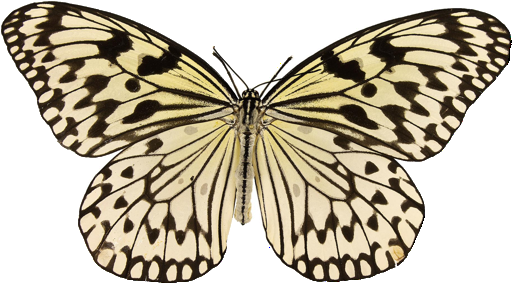

In [9]:
from datasets import load_dataset

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

print("rows:", len(dataset))
print("columns:", dataset.column_names)

dataset[0]["image"]

torch.Size([64, 3, 32, 32])


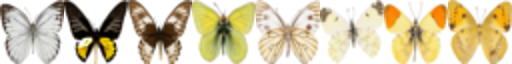

In [10]:
from torchvision import transforms

image_size = 32
batch_size = 64

preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)


def transform(examples: dict[str, list[Image.Image]]) -> dict[str, list[torch.Tensor]]:
    """Preprocess butterfly images for diffusion training.

    Args:
        examples: A batch of dataset rows containing PIL images.

    Returns:
        A dictionary with transformed image tensors.
    """
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
)

batch = next(iter(train_dataloader))
print(batch["images"].shape)

show_images = make_grid([transforms.ToPILImage()((image * 0.5 + 0.5).clamp(0, 1)) for image in batch["images"][:8]])

show_images